# **2024(R6)年度 機械学習**
# **第11週　強化学習**
## モンテカルロ法(Monte Carlo Method)
## Q学習法(Q-Learning Method)
## SARSA法(SARSA Method)
## Actor-Critic法(Actor-Critic Method)
小林 邦和＠愛知県立大学 情報科学部  
作成日: 12/26/2023  
修正日: 12/12/2024
>引用元<br>
>久保隆宏(著)「Pythonで学ぶ強化学習-入門から実践まで」講談社(2019)<br>
>https://www.kspub.co.jp/book/detail/5142981.html<br>
>サンプルコード<br>
>https://github.com/icoxfog417/baby-steps-of-rl-ja

# **準備**

## 警告の非表示(必要に応じて実行，Google Colabでは不要)

In [1]:
import warnings
warnings.filterwarnings('ignore')

## Google Driveのマウント(必要に応じて実行)

In [2]:
# if str(get_ipython()).startswith("<google.colab."):
#     from google.colab import drive
#     drive.mount('/content/drive')

## rootディレクトリの指定(必要に応じてディレクトリ名を変更の上，実行)

In [3]:
# if str(get_ipython()).startswith("<google.colab."):
#     root_dir = '/content/drive/My Drive/Colab Notebooks/4_Machine_Learning_2024/' # 要変更
# else:
#     root_dir = './'

## 強化学習フレームワーク

In [4]:
if str(get_ipython()).startswith("<google.colab."):
    !pip install gymnasium

## 日本語化Matplotlib(必要に応じて実行)

In [5]:
# if str(get_ipython()).startswith("<google.colab."):
#     !pip install japanize-matplotlib

## 各種ライブラリの読み込み

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import math
from collections import defaultdict # 辞書型オブジェクト
import gymnasium as gym # 強化学習フレームワーク
# グラフ表示で日本語を使う場合，以下2行は必須
# import japanize_matplotlib
# japanize_matplotlib.japanize()

## フラグ設定

In [7]:
# エピソード数
n_episode = 3000

#  ε-greedy法のランダムな行動選択確率の初期値(Actor-Critic法以外）
epsilon = 0.5

# 割引率
gamma = 0.9

# 学習率(モンテカルロ法以外)
learning_rate = 0.1

# マップサイズ・配置(S:Start, G:Goal, F:Frozen, H:Hole)
map_name = "4x4"
# map_name = "8x8"

# 路面が滑り易いか否か
# is_slippery = True # 意図した方向への移動確率:1/3, それと反対方向以外の２方向への移動確率:各1/3
is_slippery = False # 意図した方向への移動確率:1

# ログ表示の間隔(エピソード)
report_interval = 100

# **クラス定義**
### 引用元(久保,2019)

## エージェント

In [8]:
class Agent():
    def __init__(self, epsilon=epsilon, report_interval=report_interval): # 初期化
        self.Q = {}
        self.epsilon = epsilon
        self.reward_log = []
        self.report_interval = report_interval

    def policy(self, state, actions, episode): # ε-greedy法
        epsilon = self.epsilon * (1 / (episode + 1)) # 確率εはエピソード経過とともに減衰
        if np.random.random() < epsilon: # 確率εでランダムな行動選択
            return np.random.randint(len(actions))
        else: # 確率(1-ε)でQ値が最大となる行動選択
            if state in self.Q and sum(self.Q[state]) != 0:
                return np.argmax(self.Q[state])
            else: # Q値が初期値の場合はランダムな行動選択
                return np.random.randint(len(actions))

    def init_log(self): # 報酬ログの初期化
        self.reward_log = []

    def log(self, reward): # 報酬ログへ追加
        self.reward_log.append(reward)

    def show_reward_log(self, episode=-1): # 報酬または報酬ログの表示
        if episode > 0: # interval間隔で報酬の表示
            rewards = self.reward_log[-self.report_interval:]
            mean = np.round(np.mean(rewards), 3)
            std = np.round(np.std(rewards), 3)
            print("At Episode {} average reward is {} (+/-{}).".format(episode, mean, std))
        else: # 報酬ログの表示
            indices = list(range(0, len(self.reward_log), self.report_interval))
            means = []
            stds = []
            for i in indices:
                rewards = self.reward_log[i:(i + self.report_interval)]
                means.append(np.mean(rewards))
                stds.append(np.std(rewards))
            means = np.array(means)
            stds = np.array(stds)
            plt.figure()
            plt.fill_between(indices, means - stds, means + stds, alpha=0.1, color="g")
            plt.plot(indices, means, "o-", color="g", label="Rewards for each {} episode".format(self.report_interval))
            print("report_interval={}".format(self.report_interval))
            plt.title("Reward History")
            plt.legend(loc="best")
            plt.grid()
            plt.show()

    def draw_Q_map(self): # 報酬マップの描画
        nrow = env.unwrapped.nrow
        ncol = env.unwrapped.ncol
        state_size = 3
        q_nrow = nrow * state_size
        q_ncol = ncol * state_size
        reward_map = np.zeros((q_nrow, q_ncol))
        
        for r in range(nrow):
            for c in range(ncol):
                s = r * ncol + c
                state_exist = False
                if isinstance(self.Q, dict) and s in agent.Q:
                    state_exist = True
                elif isinstance(agent.Q, (np.ndarray, np.generic)) and s < self.Q.shape[0]:
                    state_exist = True
        
                if state_exist:
                    # At the display map, the vertical index is reversed.
                    _r = 1 + (nrow - 1 - r) * state_size
                    _c = 1 + c * state_size
                    reward_map[_r][_c - 1] = self.Q[s][0]  # LEFT = 0
                    reward_map[_r - 1][_c] = self.Q[s][1]  # DOWN = 1
                    reward_map[_r][_c + 1] = self.Q[s][2]  # RIGHT = 2
                    reward_map[_r + 1][_c] = self.Q[s][3]  # UP = 3
                    reward_map[_r][_c] = np.mean(self.Q[s])  # Center
        
        fig = plt.figure()
        ax = fig.add_subplot(1, 1, 1)
        plt.imshow(reward_map, interpolation="bilinear", vmax=abs(reward_map).max(), vmin=-abs(reward_map).max())
        ax.set_title("Q Map")
        ax.set_xlim(-0.5, q_ncol - 0.5)
        ax.set_ylim(-0.5, q_nrow - 0.5)
        ax.set_xticks(np.arange(-0.5, q_ncol, state_size))
        ax.set_yticks(np.arange(-0.5, q_nrow, state_size))
        ax.set_xticklabels(range(ncol + 1))
        ax.set_yticklabels(range(nrow + 1))
        ax.grid(which="both")
        plt.show()

## Monte Carloエージェント

In [9]:
class Monte_Carlo_Agent(Agent):
    def __init__(self, epsilon=epsilon, report_interval=report_interval): # 初期化
        super().__init__(epsilon, report_interval)
    
    def learn(self, env, n_episode=1000, gamma=0.9, render=False): # エージェントの訓練
        self.init_log()
        self.Q = defaultdict(lambda: [0] * len(actions))
        N = defaultdict(lambda: [0] * len(actions))
        actions = list(range(env.action_space.n))
        
        for e in range(n_episode): # 訓練のループ
            state, _ = env.reset()
            done = False
            experience = []
            
            while not done: # エピソードが終了していない場合
                if render:
                    env.render()
                action = self.policy(state, actions, e)
                next_state, reward, done, _, _ = env.step(action)
                
                experience.append({"state": state, "action": action, "reward": reward})
                state = next_state
            else: # エピソードが終了した場合
                self.log(reward)

            for i, x in enumerate(experience): # 状態・行動の評価
                state, action = x["state"], x["action"]

                G, t = 0, 0
                for j in range(i, len(experience)): # 総報酬の計算
                    G += math.pow(gamma, t) * experience[j]["reward"]
                    t += 1

                N[state][action] += 1  # 状態行動対(s,a)の個数計算
                alpha = 1 / N[state][action]
                self.Q[state][action] += alpha * (G - self.Q[state][action])

            if e != 0 and e % report_interval == 0: # 報告間隔毎に報酬ログの表示
                self.show_reward_log(episode=e)

## Q学習エージェント

In [10]:
class Q_Learning_Agent(Agent):
    def __init__(self, epsilon=epsilon, report_interval=report_interval): # 初期化
        super().__init__(epsilon, report_interval)

    def learn(self, env, n_episode=1000, gamma=0.9, learning_rate=0.1, render=False): # エージェントの訓練
        self.init_log()
        actions = list(range(env.action_space.n))
        self.Q = defaultdict(lambda: [0] * len(actions))
        
        for e in range(n_episode):
            state, _ = env.reset()
            done = False
            
            while not done: # エピソードが終了していない場合
                if render:
                    env.render()
                action = self.policy(state, actions, e)
                next_state, reward, done, _, _ = env.step(action)

                gain = reward + gamma * max(self.Q[next_state])
                estimated = self.Q[state][action]
                self.Q[state][action] += learning_rate * (gain - estimated)
                state = next_state
            else: # エピソードが終了した場合
                self.log(reward)

            if e != 0 and e % report_interval == 0:
                self.show_reward_log(episode=e)

## SARSAエージェント

In [11]:
class SARSA_Agent(Agent):
    def __init__(self, epsilon=epsilon, report_interval=report_interval):
        super().__init__(epsilon, report_interval)

    def learn(self, env, n_episode=1000, gamma=0.9, learning_rate=0.1, render=False):
        self.init_log()
        self.Q = defaultdict(lambda: [0] * len(actions))
        actions = list(range(env.action_space.n))
        
        for e in range(n_episode):
            state, _ = env.reset()
            done = False
            action = self.policy(state, actions, e)
            
            while not done: # エピソードが終了していない場合
                if render:
                    env.render()
                next_state, reward, done, _, _ = env.step(action)
                next_action = self.policy(next_state, actions, e)
                
                gain = reward + gamma * self.Q[next_state][next_action]
                estimated = self.Q[state][action]
                self.Q[state][action] += learning_rate * (gain - estimated)
                state = next_state
                action = next_action
            else: # エピソードが終了した場合
                self.log(reward)

            if e != 0 and e % report_interval == 0:
                self.show_reward_log(episode=e)

## Actor-Criticエージェント

### Actor(政策)

In [12]:
class Actor(Agent):
    def __init__(self, env):
        super().__init__(epsilon=-1, report_interval=report_interval)
        nrow = env.observation_space.n
        ncol = env.action_space.n
        self.actions = list(range(env.action_space.n))
        self.Q = np.random.uniform(0, 1, nrow * ncol).reshape((nrow, ncol))

    def softmax(self, x):
        return np.exp(x) / np.sum(np.exp(x), axis=0)

    def policy(self, state, episode):
        action = np.random.choice(self.actions, 1, p=self.softmax(self.Q[state]))
        return action[0]

### Critic(価値評価)

In [13]:
class Critic():
    def __init__(self, env):
        states = env.observation_space.n
        self.V = np.zeros(states)

### Actor-Criticエージェント

In [14]:
class Actor_Critic_Agent():
    def __init__(self, actor_class, critic_class):
        self.actor_class = actor_class
        self.critic_class = critic_class

    def train(self, env, n_episode=1000, gamma=0.9, learning_rate=0.1, render=False):
        actor = self.actor_class(env)
        critic = self.critic_class(env)

        actor.init_log()
        for e in range(n_episode):
            state, _ = env.reset()
            done = False
            
            while not done: # エピソードが終了していない場合
                if render:
                    env.render()
                action = actor.policy(state, e)
                next_state, reward, done, _, _ = env.step(action)
                
                gain = reward + gamma * critic.V[next_state]
                estimated = critic.V[state]
                td = gain - estimated
                actor.Q[state][action] += learning_rate * td
                critic.V[state] += learning_rate * td
                state = next_state
            else: # エピソードが終了した場合
                actor.log(reward)

            if e != 0 and e % report_interval == 0:
                actor.show_reward_log(episode=e)

        return actor, critic

# **強化学習**
## 問題設定: Frozen Lake
>https://gymnasium.farama.org/environments/toy_text/frozen_lake/#frozen-lake

## モンテカルロ法(Monte Carlo Method)
### エージェントの訓練

In [15]:
# 強化学習エージェントのインスタンス化
agent = Monte_Carlo_Agent()

# 問題設定(FrozenLake)
env = gym.make("FrozenLake-v1", map_name=map_name, is_slippery=is_slippery)

# エージェントの訓練
agent.learn(env, n_episode=n_episode, gamma=gamma)

At Episode 100 average reward is 0.0 (+/-0.0).
At Episode 200 average reward is 0.86 (+/-0.347).
At Episode 300 average reward is 0.99 (+/-0.099).
At Episode 400 average reward is 1.0 (+/-0.0).
At Episode 500 average reward is 1.0 (+/-0.0).
At Episode 600 average reward is 1.0 (+/-0.0).
At Episode 700 average reward is 1.0 (+/-0.0).
At Episode 800 average reward is 1.0 (+/-0.0).
At Episode 900 average reward is 1.0 (+/-0.0).
At Episode 1000 average reward is 1.0 (+/-0.0).
At Episode 1100 average reward is 1.0 (+/-0.0).
At Episode 1200 average reward is 1.0 (+/-0.0).
At Episode 1300 average reward is 1.0 (+/-0.0).
At Episode 1400 average reward is 0.99 (+/-0.099).
At Episode 1500 average reward is 1.0 (+/-0.0).
At Episode 1600 average reward is 1.0 (+/-0.0).
At Episode 1700 average reward is 1.0 (+/-0.0).
At Episode 1800 average reward is 1.0 (+/-0.0).
At Episode 1900 average reward is 1.0 (+/-0.0).
At Episode 2000 average reward is 1.0 (+/-0.0).
At Episode 2100 average reward is 1.0 (+

## 訓練状況の表示(獲得報酬)

report_interval=100


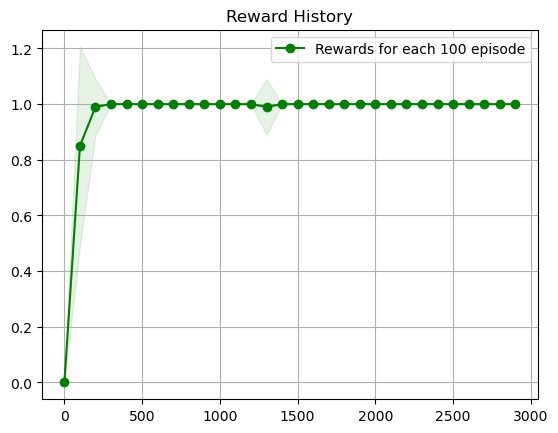

In [16]:
agent.show_reward_log()

## 報酬マップの描画

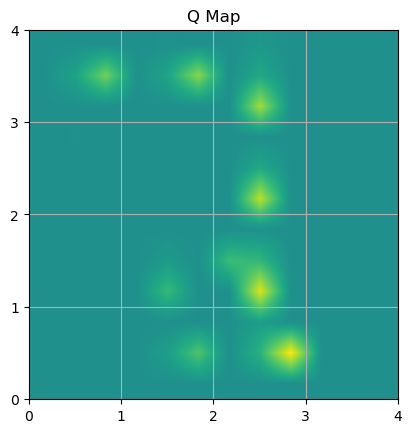

In [17]:
agent.draw_Q_map()

## Q学習法(Q-Learning Method)
### エージェントの訓練

In [18]:
# 強化学習エージェントのインスタンス化
agent = Q_Learning_Agent()

# 問題設定(FrozenLake)
env = gym.make("FrozenLake-v1", map_name=map_name, is_slippery=is_slippery)

# エージェントの訓練
agent.learn(env, n_episode=n_episode, gamma=gamma, learning_rate=learning_rate)

At Episode 100 average reward is 0.02 (+/-0.14).
At Episode 200 average reward is 0.79 (+/-0.407).
At Episode 300 average reward is 1.0 (+/-0.0).
At Episode 400 average reward is 1.0 (+/-0.0).
At Episode 500 average reward is 1.0 (+/-0.0).
At Episode 600 average reward is 1.0 (+/-0.0).
At Episode 700 average reward is 1.0 (+/-0.0).
At Episode 800 average reward is 1.0 (+/-0.0).
At Episode 900 average reward is 1.0 (+/-0.0).
At Episode 1000 average reward is 1.0 (+/-0.0).
At Episode 1100 average reward is 1.0 (+/-0.0).
At Episode 1200 average reward is 1.0 (+/-0.0).
At Episode 1300 average reward is 1.0 (+/-0.0).
At Episode 1400 average reward is 1.0 (+/-0.0).
At Episode 1500 average reward is 1.0 (+/-0.0).
At Episode 1600 average reward is 1.0 (+/-0.0).
At Episode 1700 average reward is 1.0 (+/-0.0).
At Episode 1800 average reward is 0.99 (+/-0.099).
At Episode 1900 average reward is 1.0 (+/-0.0).
At Episode 2000 average reward is 1.0 (+/-0.0).
At Episode 2100 average reward is 1.0 (+/

## 訓練状況の表示(獲得報酬)

report_interval=100


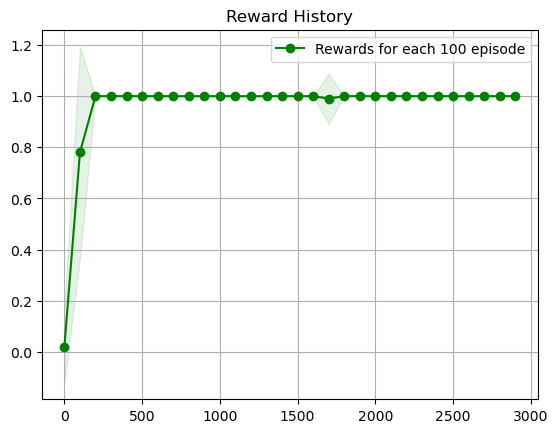

In [19]:
agent.show_reward_log()

## 報酬マップの描画

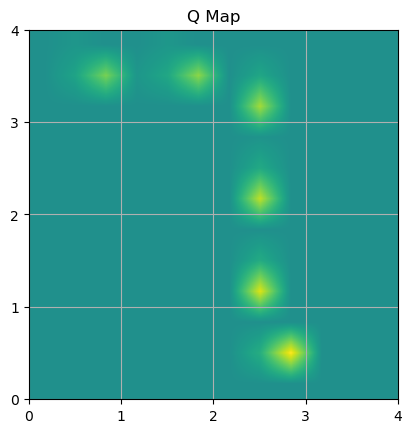

In [20]:
agent.draw_Q_map()

## SARSA法(SARSA Method)
### エージェントの訓練

In [21]:
# 強化学習エージェントのインスタンス化
agent = SARSA_Agent()

# 問題設定(FrozenLake)
env = gym.make("FrozenLake-v1", map_name=map_name, is_slippery=is_slippery)

# エージェントの訓練
agent.learn(env, n_episode=n_episode, gamma=gamma, learning_rate=learning_rate)

At Episode 100 average reward is 0.0 (+/-0.0).
At Episode 200 average reward is 0.01 (+/-0.099).
At Episode 300 average reward is 0.49 (+/-0.5).
At Episode 400 average reward is 1.0 (+/-0.0).
At Episode 500 average reward is 1.0 (+/-0.0).
At Episode 600 average reward is 1.0 (+/-0.0).
At Episode 700 average reward is 1.0 (+/-0.0).
At Episode 800 average reward is 1.0 (+/-0.0).
At Episode 900 average reward is 1.0 (+/-0.0).
At Episode 1000 average reward is 1.0 (+/-0.0).
At Episode 1100 average reward is 1.0 (+/-0.0).
At Episode 1200 average reward is 1.0 (+/-0.0).
At Episode 1300 average reward is 1.0 (+/-0.0).
At Episode 1400 average reward is 1.0 (+/-0.0).
At Episode 1500 average reward is 1.0 (+/-0.0).
At Episode 1600 average reward is 1.0 (+/-0.0).
At Episode 1700 average reward is 1.0 (+/-0.0).
At Episode 1800 average reward is 1.0 (+/-0.0).
At Episode 1900 average reward is 1.0 (+/-0.0).
At Episode 2000 average reward is 1.0 (+/-0.0).
At Episode 2100 average reward is 1.0 (+/-0.0

## 訓練状況の表示(獲得報酬)

report_interval=100


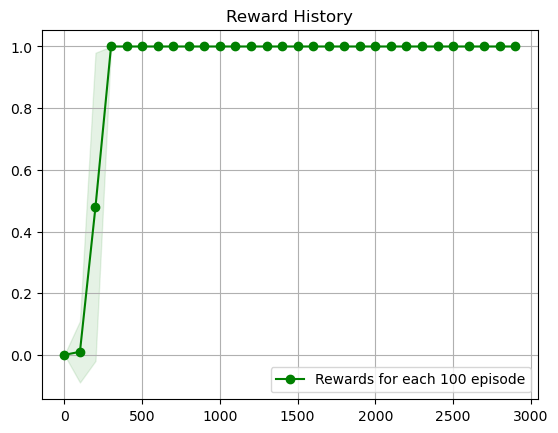

In [22]:
agent.show_reward_log()

## 報酬マップの描画

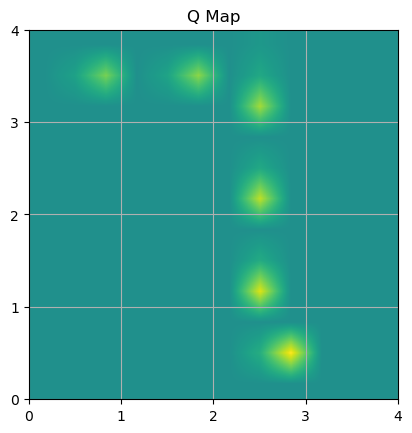

In [23]:
agent.draw_Q_map()

## Actor-Critic法(Actor-Critic Method)
### エージェントの訓練

In [24]:
# 強化学習エージェントのインスタンス化
trainer = Actor_Critic_Agent(Actor, Critic)

# 問題設定(FrozenLake)
env = gym.make("FrozenLake-v1", map_name=map_name, is_slippery=is_slippery)

# エージェントの訓練
actor, critic = trainer.train(env, n_episode=n_episode, gamma=gamma, learning_rate=learning_rate)

At Episode 100 average reward is 0.01 (+/-0.099).
At Episode 200 average reward is 0.03 (+/-0.171).
At Episode 300 average reward is 0.0 (+/-0.0).
At Episode 400 average reward is 0.01 (+/-0.099).
At Episode 500 average reward is 0.0 (+/-0.0).
At Episode 600 average reward is 0.03 (+/-0.171).
At Episode 700 average reward is 0.02 (+/-0.14).
At Episode 800 average reward is 0.05 (+/-0.218).
At Episode 900 average reward is 0.08 (+/-0.271).
At Episode 1000 average reward is 0.12 (+/-0.325).
At Episode 1100 average reward is 0.16 (+/-0.367).
At Episode 1200 average reward is 0.45 (+/-0.497).
At Episode 1300 average reward is 0.62 (+/-0.485).
At Episode 1400 average reward is 0.88 (+/-0.325).
At Episode 1500 average reward is 0.88 (+/-0.325).
At Episode 1600 average reward is 0.92 (+/-0.271).
At Episode 1700 average reward is 0.94 (+/-0.237).
At Episode 1800 average reward is 0.99 (+/-0.099).
At Episode 1900 average reward is 0.98 (+/-0.14).
At Episode 2000 average reward is 0.94 (+/-0.237

## 訓練状況の表示(獲得報酬)

report_interval=100


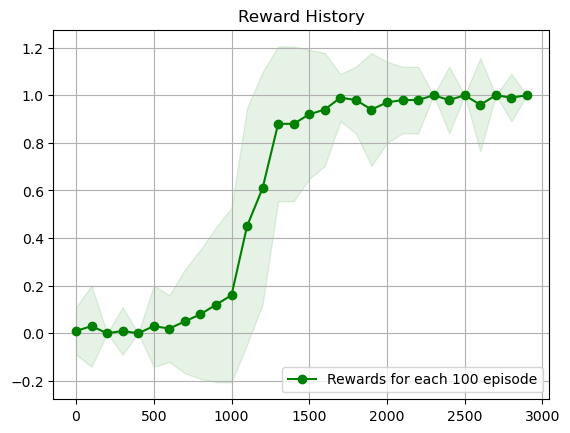

In [25]:
agent = actor
agent.show_reward_log()

## 報酬マップの描画

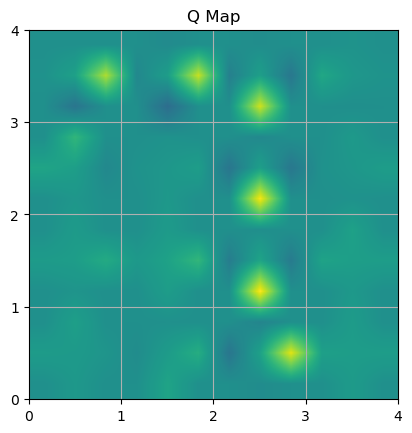

In [26]:
agent.draw_Q_map()